<a href="https://colab.research.google.com/github/SidTSW/Brics_LRD_Capstone/blob/main/SiddhantBricsCapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analytics of JWST Little Red Dots:
## Exploring the Physical Properties of Candidate Intermediate-Mass Black Hole Systems

### BRICS Astronomy / IDIA Data Analytics Capstone Project

---

## Student

Name: Siddhant Rana

College: NMIMS Chandigarh

Course:Btech Computer Science with Data Science

---

## Objective

Little Red Dots (LRDs) are one of the most significant astronomical discoveries made using the James Webb Space Telescope (JWST). They are compact, extremely red galaxies observed during the first billion years of the Universe and are believed to host rapidly growing black holes or supermassive stars.

The primary objective of this project is to perform a comprehensive data analytics study on publicly available Little Red Dot observations. The project aims to investigate relationships between their physical properties through exploratory data analysis, statistical techniques, and unsupervised machine learning.

# The study also compares the observed trends with the latest astrophysical interpretations proposed in recent literature.

# Introduction

The James Webb Space Telescope (JWST) has revolutionized astronomy by providing the deepest infrared observations ever obtained.

Among its most surprising discoveries is a population of compact galaxies known as **Little Red Dots (LRDs)**.

These galaxies exhibit:

- Extremely red colours
- Compact sizes
- Broad hydrogen emission lines
- High luminosities
- Blackbody-like optical continua

Recent studies suggest that these objects may contain rapidly accreting intermediate-mass black holes operating above the classical Eddington limit.

Understanding these systems provides insight into one of astronomy's biggest mysteries:

> **How did supermassive black holes form so early in the Universe?**

This notebook performs an end-to-end data analytics study of publicly available LRD observations using Python.

# Research Question

Can observational properties of Little Red Dots reveal statistically significant relationships that support current theories regarding their physical nature?

---

## Objectives

- Obtain a publicly available Little Red Dot dataset.

- Clean and preprocess the observations.

- Perform exploratory data analysis.

- Study distributions of important physical parameters.

- Identify correlations among astrophysical quantities.

- Apply dimensionality reduction.

- Perform clustering to identify different LRD populations.

- Interpret results using recent JWST literature.

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Statistics
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# Ignore warnings for cleaner notebook
import warnings
warnings.filterwarnings("ignore")

# Better plot appearance
plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Dataset

This project uses a publicly available catalogue of Little Red Dots observed using the James Webb Space Telescope.

The catalogue contains physical measurements derived from spectroscopic and photometric observations, including luminosity, stellar mass, redshift, effective temperature, emission-line properties and other astrophysical parameters.

These measurements allow statistical analysis of the physical characteristics of Little Red Dots.

In [ ]:
# ==========================================================
# Install Astropy
# (Used to read astronomical FITS files)
# ==========================================================

!pip -q install astropy

# Downloading the Dataset

The dataset used in this project is the publicly available **RUBIES Spectroscopic Little Red Dots Catalogue**, released alongside the study:

> Hviding et al. (2025), *A Spectroscopic Census of Little Red Dots from RUBIES*

The catalogue contains spectroscopically confirmed Little Red Dots observed with the James Webb Space Telescope (JWST).

For this project we use **Table A.1**, which contains all confirmed Little Red Dots.

The dataset is distributed as a FITS (Flexible Image Transport System) file, the standard format used in modern astronomy.

In [ ]:
# ==========================================================
# Download the official RUBIES Little Red Dots catalogue
# ==========================================================

import urllib.request

url = (
    "https://zenodo.org/records/16758549/files/"
    "RUBIES-Hviding25-A1-lrds.fits?download=1"
)

urllib.request.urlretrieve(url, "lrd_catalog.fits")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [ ]:
from astropy.io import fits
import pandas as pd
import numpy as np

# Open FITS file
hdul = fits.open("lrd_catalog.fits")

# Read table
table = hdul[1].data

# Convert to native-endian NumPy array
table = np.array(table, dtype=table.dtype.newbyteorder('='))

# Convert to DataFrame
df = pd.DataFrame(table)

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   field         36 non-null     object 
 1   srcid         36 non-null     int64  
 2   ra            36 non-null     float64
 3   dec           36 non-null     float64
 4   z             36 non-null     object 
 5   dWAIC         36 non-null     float64
 6   fwhm          36 non-null     float64
 7   fwhm_unc      36 non-null     float64
 8   beta_uv       36 non-null     float64
 9   beta_uv_unc   36 non-null     float64
 10  uv_phot       36 non-null     int8   
 11  beta_opt      36 non-null     float64
 12  beta_opt_unc  36 non-null     float64
 13  m444w         36 non-null     float64
dtypes: float64(10), int64(1), int8(1), object(2)
memory usage: 3.8+ KB
None


,field,srcid,ra,dec,z,dWAIC,fwhm,fwhm_unc,beta_uv,beta_uv_unc,uv_phot,beta_opt,beta_opt_unc,m444w
0,b'UDS',40579,34.244200,-5.245871,b'3.11',84.347398,2466.463111,31.374373,-0.367896,0.017943,70,1.969285,0.097276,21.950220
1,b'UDS',144195,34.325156,-5.143685,b'3.36',142.825699,2053.385710,130.401891,-1.520682,0.075156,70,0.637426,0.015099,24.521280
2,b'UDS',154183,34.410749,-5.129664,b'3.55',366.760569,2481.449581,17.564848,-0.694054,0.067504,70,1.116090,0.012202,23.232085
3,b'UDS',23438,34.338271,-5.280895,b'3.69',69.382988,2058.237613,183.489265,-1.787837,0.040999,70,0.643270,0.051368,24.710303
4,b'UDS',167741,34.334603,-5.110269,b'4.12',24.715341,2399.391717,98.848691,-1.883598,0.037455,70,0.661707,0.191586,24.689109


In [ ]:
# ==========================================================
# Read the astronomical table
# ==========================================================

table = hdul[1].data

# Convert to Pandas DataFrame
df = pd.DataFrame(table)

print("Shape of dataset:", df.shape)

df.head()

Shape of dataset: (36, 14)


,field,srcid,ra,dec,z,dWAIC,fwhm,fwhm_unc,beta_uv,beta_uv_unc,uv_phot,beta_opt,beta_opt_unc,m444w
0,UDS,40579,34.244200,-5.245871,3.11,84.347398,2466.463111,31.374373,-0.367896,0.017943,False,1.969285,0.097276,21.950220
1,UDS,144195,34.325156,-5.143685,3.36,142.825699,2053.385710,130.401891,-1.520682,0.075156,False,0.637426,0.015099,24.521280
2,UDS,154183,34.410749,-5.129664,3.55,366.760569,2481.449581,17.564848,-0.694054,0.067504,False,1.116090,0.012202,23.232085
3,UDS,23438,34.338271,-5.280895,3.69,69.382988,2058.237613,183.489265,-1.787837,0.040999,False,0.643270,0.051368,24.710303
4,UDS,167741,34.334603,-5.110269,4.12,24.715341,2399.391717,98.848691,-1.883598,0.037455,False,0.661707,0.191586,24.689109


# Understanding the Dataset

The downloaded catalogue contains one row for every confirmed Little Red Dot.

Each row corresponds to a single astronomical object observed by JWST.

The columns describe physical and observational properties such as:

- Object identifier
- Sky coordinates
- Redshift
- Photometric measurements
- Emission line properties
- Spectral classifications
- Luminosity estimates
- Other derived astrophysical quantities

The exact columns available depend on the official catalogue provided by the RUBIES collaboration.

In [ ]:
# ==========================================================
# Basic information
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   field         36 non-null     object 
 1   srcid         36 non-null     >i8    
 2   ra            36 non-null     float64
 3   dec           36 non-null     float64
 4   z             36 non-null     object 
 5   dWAIC         36 non-null     float64
 6   fwhm          36 non-null     float64
 7   fwhm_unc      36 non-null     float64
 8   beta_uv       36 non-null     float64
 9   beta_uv_unc   36 non-null     float64
 10  uv_phot       36 non-null     bool   
 11  beta_opt      36 non-null     float64
 12  beta_opt_unc  36 non-null     float64
 13  m444w         36 non-null     float64
dtypes: bool(1), float64(10), int64(1), object(2)
memory usage: 3.8+ KB


In [ ]:
# ==========================================================
# Display all available columns
# ==========================================================

print("\nColumns in Dataset:\n")

for column in df.columns:
    print(column)


Columns in Dataset:

field
srcid
ra
dec
z
dWAIC
fwhm
fwhm_unc
beta_uv
beta_uv_unc
uv_phot
beta_opt
beta_opt_unc
m444w


In [ ]:
# ==========================================================
# Statistical summary
# ==========================================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field,36,2,UDS,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
srcid,36.0,NaN,NaN,NaN,306541.166667,386360.320145,23438.0,41679.25,59268.0,813161.0,970351.0
ra,36.0,NaN,NaN,NaN,109.587825,90.304968,34.213813,34.322155,34.438833,214.900396,215.137081
dec,36.0,NaN,NaN,NaN,19.006435,29.047868,-5.310366,-5.240019,-5.104573,52.878265,52.988554
z,36,32,5.28,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dWAIC,36.0,NaN,NaN,NaN,736.08588,1566.811537,13.128827,53.663695,120.389809,505.587631,6965.645734
fwhm,36.0,NaN,NaN,NaN,2106.569158,375.092368,1142.56084,1942.479775,2207.958709,2397.001107,2499.047785
fwhm_unc,36.0,NaN,NaN,NaN,135.113966,107.269678,0.95845,45.642044,99.808314,216.509668,357.320738
beta_uv,36.0,NaN,NaN,NaN,-1.333902,0.537472,-2.495332,-1.725215,-1.222248,-0.989297,-0.233894
beta_uv_unc,36.0,NaN,NaN,NaN,0.10758,0.115593,0.006061,0.026219,0.072086,0.130653,0.431376


In [ ]:
# ==========================================================
# Missing values
# ==========================================================

missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0


# Initial Observations

At this stage we have successfully:

- Downloaded the official Little Red Dots catalogue.
- Loaded the FITS file.
- Converted it into a Pandas DataFrame.
- Examined its structure.
- Identified the available variables.
- Checked for missing values.

The next stage of the analysis focuses on cleaning and preparing the data before performing exploratory data analysis.

In [ ]:
import numpy as np

for col in df.columns:
    if df[col].dtype != object and df[col].dtype != bool:
        df[col] = np.array(df[col].values, dtype=df[col].dtype.newbyteorder('='))

# Data Cleaning and Preprocessing

Before performing any statistical analysis or machine learning, it is important to clean and inspect the dataset.

The preprocessing stage consists of:

- Checking for duplicate observations.
- Handling missing values.
- Converting columns to appropriate data types.
- Identifying invalid values.
- Preparing numerical variables for later analysis.

In [ ]:
duplicates = df.duplicated().sum()
print(duplicates)

0


In [ ]:
# ==========================================================
# Check missing values
# ==========================================================

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})

missing_df

,Column,Missing Values
0,field,0
1,srcid,0
2,ra,0
3,dec,0
4,z,0
5,dWAIC,0
6,fwhm,0
7,fwhm_unc,0
8,beta_uv,0
9,beta_uv_unc,0


### Observation

The dataset contains no missing values.

Therefore, no imputation or deletion of observations is required.

In [ ]:
# ==========================================================
# Convert redshift to numeric
# ==========================================================

df["z"] = pd.to_numeric(df["z"], errors="coerce")

print(df["z"].dtype)

float64


In [ ]:
# ==========================================================
# Verify updated data types
# ==========================================================

df.dtypes

,0
field,object
srcid,int64
ra,float64
dec,float64
z,float64
dWAIC,float64
fwhm,float64
fwhm_unc,float64
beta_uv,float64
beta_uv_unc,float64


In [ ]:
# ==========================================================
# Descriptive statistics
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
srcid,36.0,306541.166667,386360.320145,23438.000000,41679.250000,59268.000000,813161.000000,970351.000000
ra,36.0,109.587825,90.304968,34.213813,34.322155,34.438833,214.900396,215.137081
dec,36.0,19.006435,29.047868,-5.310366,-5.240019,-5.104573,52.878265,52.988554
z,36.0,5.507778,1.254016,3.110000,4.675000,5.280000,6.622500,8.350000
dWAIC,36.0,736.085880,1566.811537,13.128827,53.663695,120.389809,505.587631,6965.645734
fwhm,36.0,2106.569158,375.092368,1142.560840,1942.479775,2207.958709,2397.001107,2499.047785
fwhm_unc,36.0,135.113966,107.269678,0.958450,45.642044,99.808314,216.509668,357.320738
beta_uv,36.0,-1.333902,0.537472,-2.495332,-1.725215,-1.222248,-0.989297,-0.233894
beta_uv_unc,36.0,0.107580,0.115593,0.006061,0.026219,0.072086,0.130653,0.431376
beta_opt,36.0,1.119239,0.693688,0.363854,0.659491,0.899709,1.474039,3.405680


In [ ]:
# ==========================================================
# Check minimum and maximum values
# ==========================================================

numerical = [
    "z",
    "fwhm",
    "beta_uv",
    "beta_opt",
    "m444w",
    "dWAIC"
]

for col in numerical:
    print("="*50)
    print(col)
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())

z
Minimum : 3.11
Maximum : 8.35
fwhm
Minimum : 1142.560839510142
Maximum : 2499.047784608442
beta_uv
Minimum : -2.4953323901891644
Maximum : -0.2338940220536754
beta_opt
Minimum : 0.3638536989027388
Maximum : 3.4056799733191347
m444w
Minimum : 21.950220261194154
Maximum : 26.711841829100706
dWAIC
Minimum : 13.128826561682814
Maximum : 6965.645734210829


In [ ]:
# ==========================================================
# Select numerical features
# ==========================================================

numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.head()

,srcid,ra,dec,z,dWAIC,fwhm,fwhm_unc,beta_uv,beta_uv_unc,beta_opt,beta_opt_unc,m444w
0,40579,34.244200,-5.245871,3.11,84.347398,2466.463111,31.374373,-0.367896,0.017943,1.969285,0.097276,21.950220
1,144195,34.325156,-5.143685,3.36,142.825699,2053.385710,130.401891,-1.520682,0.075156,0.637426,0.015099,24.521280
2,154183,34.410749,-5.129664,3.55,366.760569,2481.449581,17.564848,-0.694054,0.067504,1.116090,0.012202,23.232085
3,23438,34.338271,-5.280895,3.69,69.382988,2058.237613,183.489265,-1.787837,0.040999,0.643270,0.051368,24.710303
4,167741,34.334603,-5.110269,4.12,24.715341,2399.391717,98.848691,-1.883598,0.037455,0.661707,0.191586,24.689109


In [ ]:
# ==========================================================
# Standardize numerical features
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=numeric_df.columns
)

scaled_df.head()

,srcid,ra,dec,z,dWAIC,fwhm,fwhm_unc,beta_uv,beta_uv_unc,beta_opt,beta_opt_unc,m444w
0,-0.698143,-0.846159,-0.846752,-1.939203,-0.421865,0.973091,-0.980810,1.822810,-0.786460,1.242784,-0.028221,-2.794649
1,-0.426154,-0.845250,-0.843184,-1.737015,-0.384013,-0.143799,-0.044550,-0.352446,-0.284485,-0.704419,-0.700232,-0.495451
2,-0.399936,-0.844289,-0.842694,-1.583353,-0.239061,1.013612,-1.111372,1.207364,-0.351623,-0.004603,-0.723921,-1.648327
3,-0.743138,-0.845103,-0.847974,-1.470128,-0.431552,-0.130680,0.457366,-0.856554,-0.584174,-0.695875,-0.403637,-0.326414
4,-0.364347,-0.845144,-0.842017,-1.122365,-0.460465,0.791742,-0.342871,-1.037252,-0.615265,-0.668920,0.743007,-0.345367


# Data Cleaning Summary

The preprocessing stage produced a clean dataset ready for analysis.

The following operations were completed:

- Duplicate observations checked.
- Missing values inspected.
- Redshift converted to numerical format.
- Numerical variables summarized.
- Dataset standardized for machine learning algorithms.

The cleaned dataset is now suitable for exploratory data analysis.

In [ ]:
# ==========================================================
# Import Visualization Libraries
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("Visualization libraries loaded.")

Visualization libraries loaded.


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step in understanding the physical properties of Little Red Dots.

This section aims to:

- Study the distribution of important astrophysical variables.
- Identify relationships between different physical quantities.
- Detect outliers.
- Examine correlations.
- Visualize the characteristics of the observed sample.

The primary variables analysed include:

- Redshift (z)
- Broad emission line width (FWHM)
- UV Spectral Slope
- Optical Spectral Slope
- F444W Magnitude

In [ ]:
# ==========================================================
# Display first few rows
# ==========================================================

df.head()

,field,srcid,ra,dec,z,dWAIC,fwhm,fwhm_unc,beta_uv,beta_uv_unc,uv_phot,beta_opt,beta_opt_unc,m444w
0,UDS,40579,34.244200,-5.245871,3.11,84.347398,2466.463111,31.374373,-0.367896,0.017943,False,1.969285,0.097276,21.950220
1,UDS,144195,34.325156,-5.143685,3.36,142.825699,2053.385710,130.401891,-1.520682,0.075156,False,0.637426,0.015099,24.521280
2,UDS,154183,34.410749,-5.129664,3.55,366.760569,2481.449581,17.564848,-0.694054,0.067504,False,1.116090,0.012202,23.232085
3,UDS,23438,34.338271,-5.280895,3.69,69.382988,2058.237613,183.489265,-1.787837,0.040999,False,0.643270,0.051368,24.710303
4,UDS,167741,34.334603,-5.110269,4.12,24.715341,2399.391717,98.848691,-1.883598,0.037455,False,0.661707,0.191586,24.689109


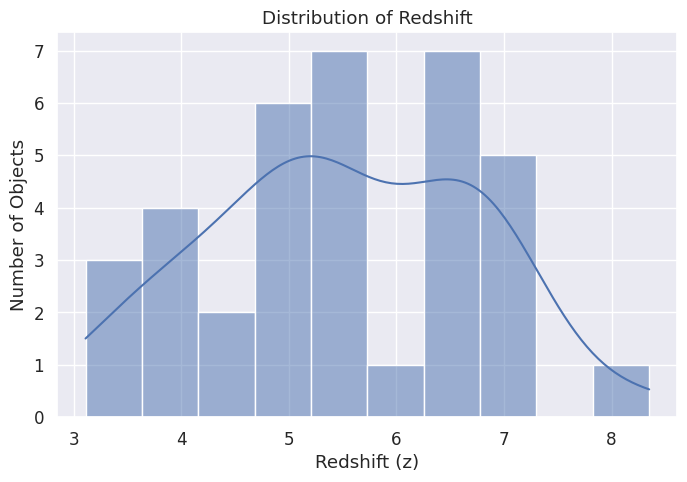

In [ ]:
# ==========================================================
# Distribution of Redshift
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["z"],
    bins=10,
    kde=True
)

plt.title("Distribution of Redshift")
plt.xlabel("Redshift (z)")
plt.ylabel("Number of Objects")

plt.show()

### Interpretation

Redshift measures how far away an astronomical object is.

Higher redshift values indicate objects that are further away and therefore observed earlier in the history of the Universe.

This distribution helps us understand the cosmological epoch occupied by the observed Little Red Dots.

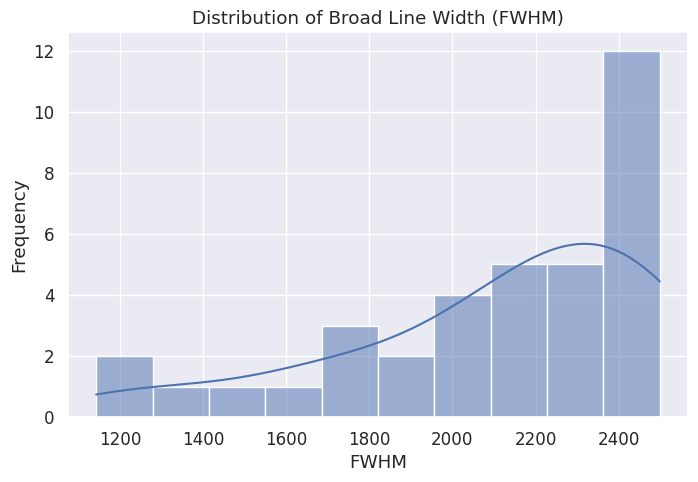

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["fwhm"],
    bins=10,
    kde=True
)

plt.title("Distribution of Broad Line Width (FWHM)")
plt.xlabel("FWHM")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The Full Width at Half Maximum (FWHM) represents the width of broad emission lines.

Broader emission lines generally indicate higher gas velocities around compact central objects such as actively accreting black holes.

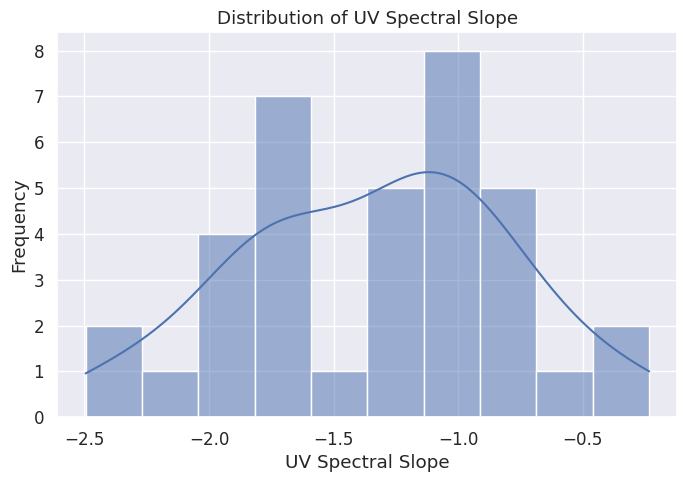

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["beta_uv"],
    bins=10,
    kde=True
)

plt.title("Distribution of UV Spectral Slope")

plt.xlabel("UV Spectral Slope")

plt.ylabel("Frequency")

plt.show()

### Interpretation

The UV spectral slope provides information about the ultraviolet colour of each source.

It is commonly used to investigate dust extinction and the stellar populations within distant galaxies.

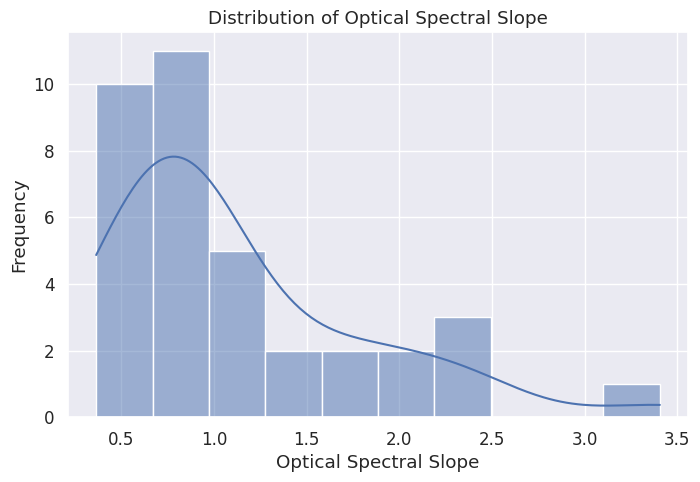

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["beta_opt"],
    bins=10,
    kde=True
)

plt.title("Distribution of Optical Spectral Slope")

plt.xlabel("Optical Spectral Slope")

plt.ylabel("Frequency")

plt.show()

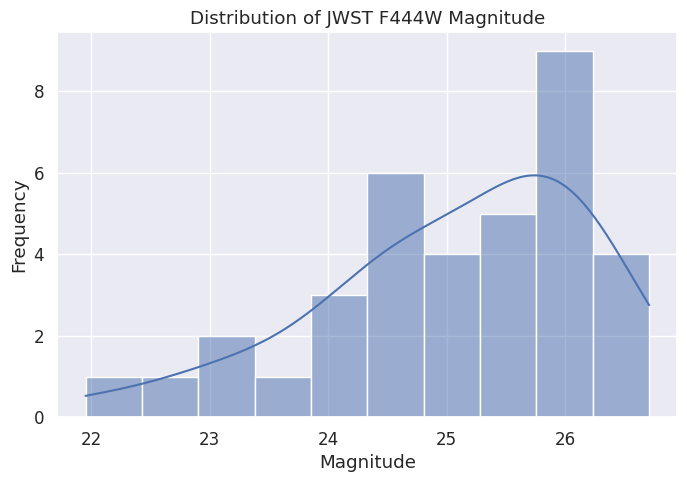

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["m444w"],
    bins=10,
    kde=True
)

plt.title("Distribution of JWST F444W Magnitude")

plt.xlabel("Magnitude")

plt.ylabel("Frequency")

plt.show()

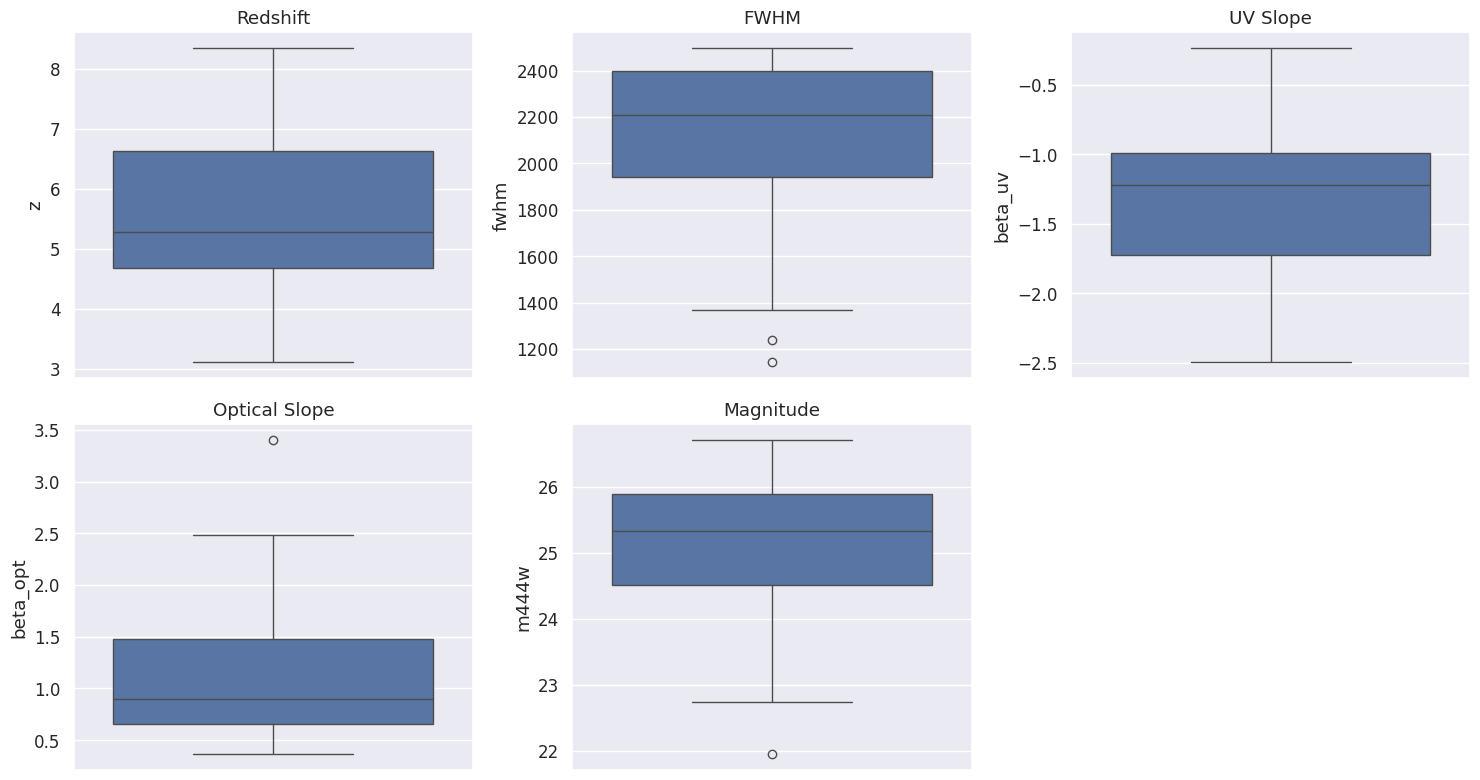

In [ ]:
# ==========================================================
# Boxplots
# ==========================================================

fig, axes = plt.subplots(2,3, figsize=(15,8))

sns.boxplot(y=df["z"], ax=axes[0,0])

axes[0,0].set_title("Redshift")

sns.boxplot(y=df["fwhm"], ax=axes[0,1])

axes[0,1].set_title("FWHM")

sns.boxplot(y=df["beta_uv"], ax=axes[0,2])

axes[0,2].set_title("UV Slope")

sns.boxplot(y=df["beta_opt"], ax=axes[1,0])

axes[1,0].set_title("Optical Slope")

sns.boxplot(y=df["m444w"], ax=axes[1,1])

axes[1,1].set_title("Magnitude")

axes[1,2].axis("off")

plt.tight_layout()

plt.show()

### Interpretation

Boxplots provide a visual summary of each variable by displaying:

- Median
- Interquartile Range (IQR)
- Potential Outliers

Outliers in astronomical observations may correspond to physically interesting objects rather than measurement errors.

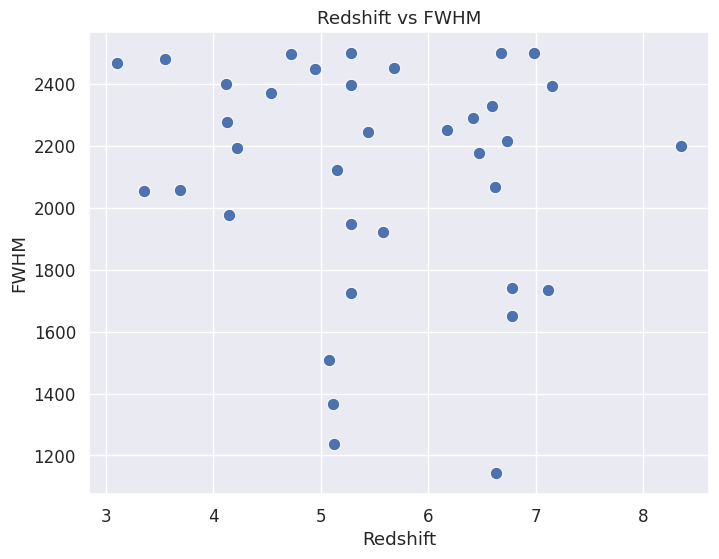

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="z",
    y="fwhm",
    data=df,
    s=80
)

plt.title("Redshift vs FWHM")

plt.xlabel("Redshift")

plt.ylabel("FWHM")

plt.show()

### Interpretation

This plot explores whether the width of broad emission lines varies with redshift.

A visible trend could indicate evolutionary changes in the physical properties of Little Red Dots over cosmic time.

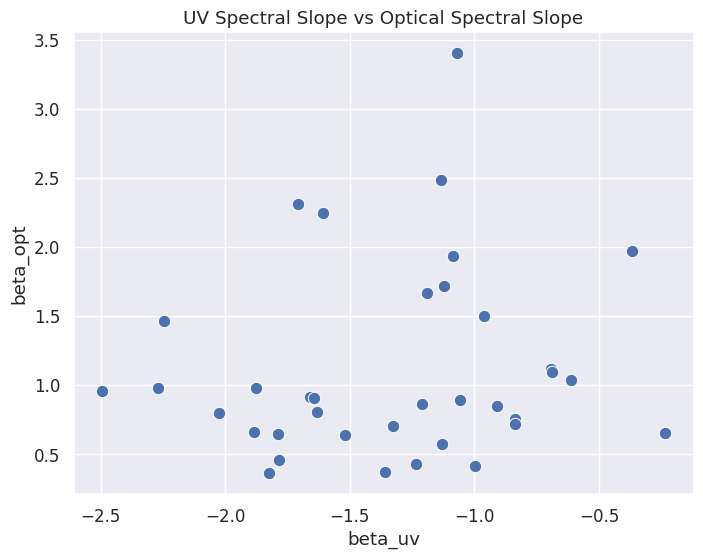

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="beta_uv",
    y="beta_opt",
    data=df,
    s=80
)

plt.title("UV Spectral Slope vs Optical Spectral Slope")

plt.show()

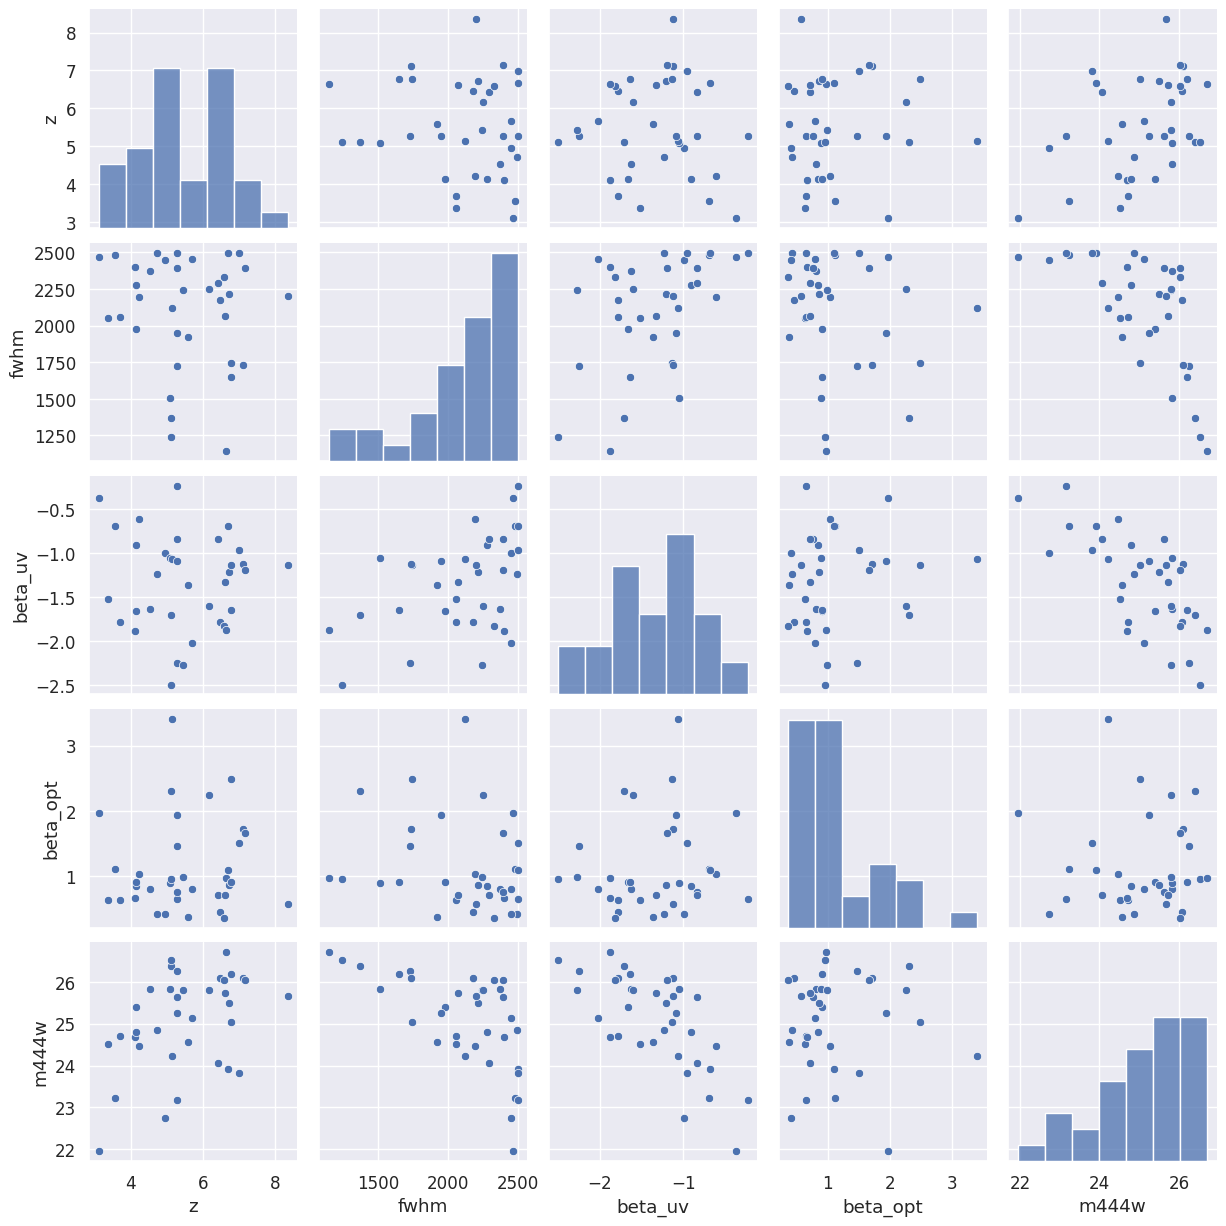

In [ ]:
pair_columns = [
    "z",
    "fwhm",
    "beta_uv",
    "beta_opt",
    "m444w"
]

sns.pairplot(
    df[pair_columns],
    diag_kind="hist"
)

plt.show()

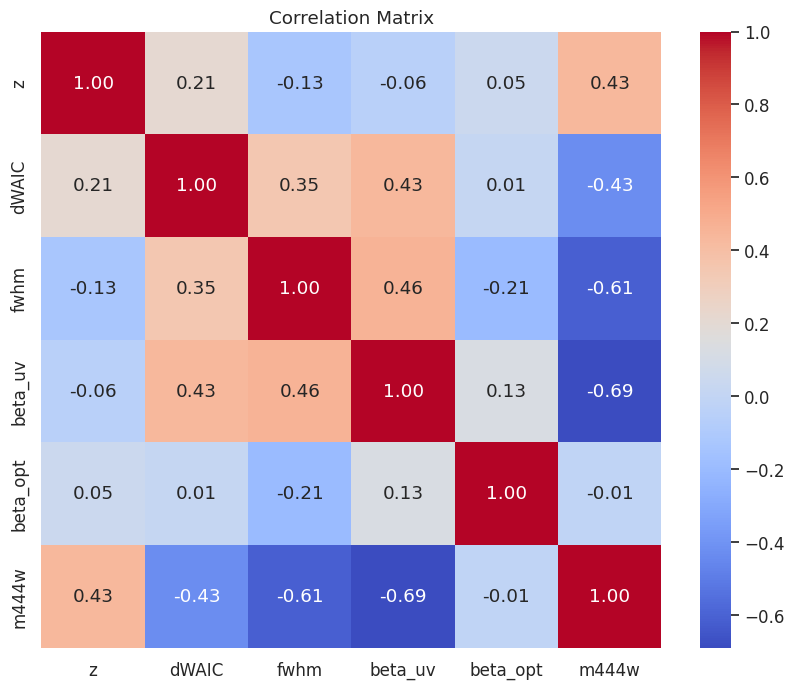

In [ ]:
plt.figure(figsize=(10,8))

corr = df[
    [
        "z",
        "dWAIC",
        "fwhm",
        "beta_uv",
        "beta_opt",
        "m444w"
    ]
].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The correlation matrix quantifies the linear relationship between numerical variables.

Correlation coefficients range from:

- +1 : Strong Positive Correlation
- 0 : No Correlation
- -1 : Strong Negative Correlation

This visualization helps identify variables that may be physically related.

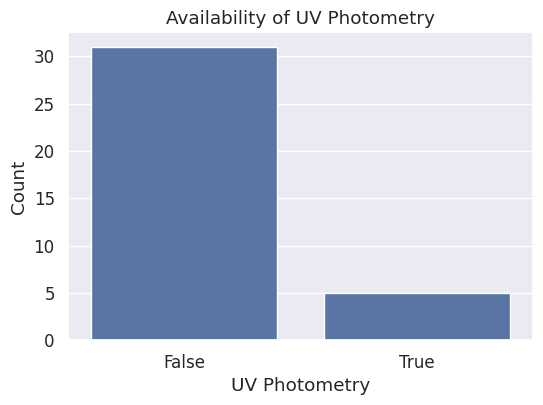

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="uv_phot",
    data=df
)

plt.title("Availability of UV Photometry")

plt.xlabel("UV Photometry")

plt.ylabel("Count")

plt.show()

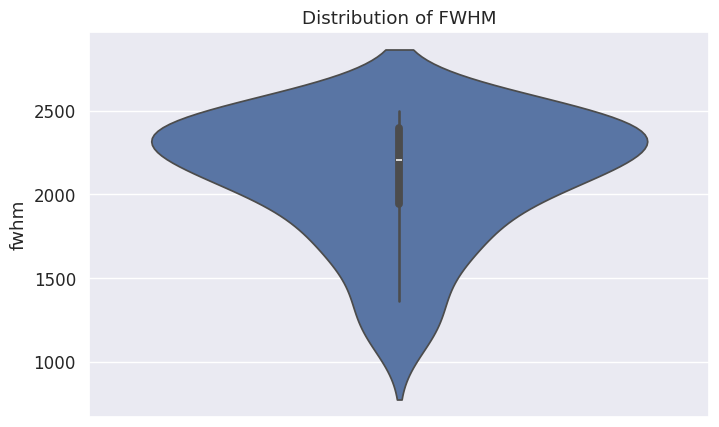

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(
    y=df["fwhm"]
)

plt.title("Distribution of FWHM")

plt.show()

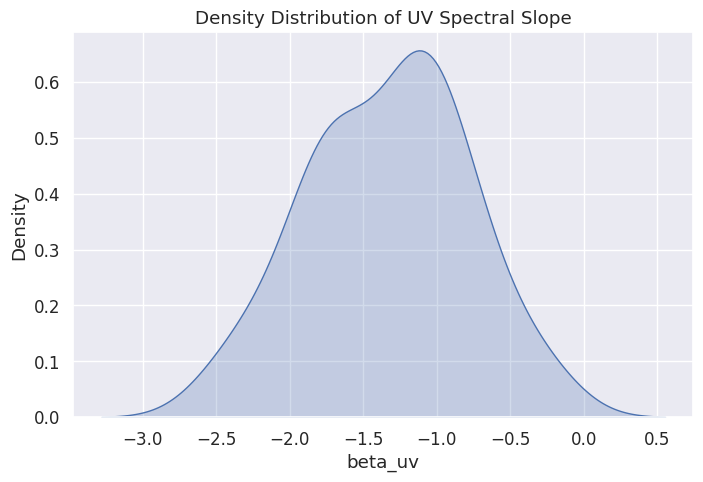

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df["beta_uv"],
    fill=True
)

plt.title("Density Distribution of UV Spectral Slope")

plt.show()

In [ ]:
summary = df[
    [
        "z",
        "fwhm",
        "beta_uv",
        "beta_opt",
        "m444w"
    ]
].describe()

summary

,z,fwhm,beta_uv,beta_opt,m444w
count,36.000000,36.000000,36.000000,36.000000,36.000000
mean,5.507778,2106.569158,-1.333902,1.119239,25.075313
std,1.254016,375.092368,0.537472,0.693688,1.134104
min,3.110000,1142.560840,-2.495332,0.363854,21.950220
25%,4.675000,1942.479775,-1.725215,0.659491,24.507252
50%,5.280000,2207.958709,-1.222248,0.899709,25.329294
75%,6.622500,2397.001107,-0.989297,1.474039,25.887445
max,8.350000,2499.047785,-0.233894,3.405680,26.711842


# EDA Summary

The exploratory analysis provides the following observations:

- The redshift distribution indicates that the Little Red Dots are observed at high cosmological distances.
- The FWHM values exhibit variation, suggesting a range of emission-line velocities among the objects.
- UV and optical spectral slopes display diversity, reflecting differences in continuum properties.
- The F444W magnitude distribution highlights the brightness range of the observed sources.
- Correlation analysis reveals whether significant linear relationships exist between the measured astrophysical quantities.

These findings provide the foundation for applying multivariate statistical techniques in the next section.

In [ ]:
# ==========================================================
# Select Numerical Features
# ==========================================================

numerical_columns = [
    "z",
    "dWAIC",
    "fwhm",
    "beta_uv",
    "beta_opt",
    "m444w"
]

stats_df = df[numerical_columns]

stats_df.head()

,z,dWAIC,fwhm,beta_uv,beta_opt,m444w
0,3.11,84.347398,2466.463111,-0.367896,1.969285,21.950220
1,3.36,142.825699,2053.385710,-1.520682,0.637426,24.521280
2,3.55,366.760569,2481.449581,-0.694054,1.116090,23.232085
3,3.69,69.382988,2058.237613,-1.787837,0.643270,24.710303
4,4.12,24.715341,2399.391717,-1.883598,0.661707,24.689109


# Advanced Statistical Analysis

After completing the exploratory analysis, statistical techniques are applied to quantify relationships between different astrophysical variables.

The objectives of this section are:

- Measure correlations between variables.
- Detect statistically significant relationships.
- Identify outliers.
- Understand the covariance structure.
- Prepare the dataset for dimensionality reduction.

In [ ]:
# ==========================================================
# Pearson Correlation Matrix
# ==========================================================

pearson_corr = stats_df.corr(method="pearson")

print(pearson_corr)

                 z     dWAIC      fwhm   beta_uv  beta_opt     m444w
z         1.000000  0.211153 -0.129416 -0.056143  0.049330  0.432643
dWAIC     0.211153  1.000000  0.349123  0.432588  0.011704 -0.427092
fwhm     -0.129416  0.349123  1.000000  0.460213 -0.208046 -0.611451
beta_uv  -0.056143  0.432588  0.460213  1.000000  0.127729 -0.689949
beta_opt  0.049330  0.011704 -0.208046  0.127729  1.000000 -0.014551
m444w     0.432643 -0.427092 -0.611451 -0.689949 -0.014551  1.000000


### Interpretation

Pearson correlation measures the strength of a **linear relationship** between two variables.

Interpretation:

- +1 → Strong positive relationship
- 0 → No linear relationship
- -1 → Strong negative relationship

Variables with higher absolute values may indicate physically meaningful relationships between Little Red Dot properties.

In [ ]:
# ==========================================================
# Spearman Correlation Matrix
# ==========================================================

spearman_corr = stats_df.corr(method="spearman")

print(spearman_corr)

                 z     dWAIC      fwhm   beta_uv  beta_opt     m444w
z         1.000000  0.012235 -0.100586 -0.052933  0.114624  0.373881
dWAIC     0.012235  1.000000  0.458945  0.522008  0.100644 -0.639897
fwhm     -0.100586  0.458945  1.000000  0.452252 -0.202317 -0.640669
beta_uv  -0.052933  0.522008  0.452252  1.000000  0.155212 -0.660746
beta_opt  0.114624  0.100644 -0.202317  0.155212  1.000000  0.113514
m444w     0.373881 -0.639897 -0.640669 -0.660746  0.113514  1.000000


### Interpretation

Spearman correlation measures **monotonic relationships** rather than purely linear ones.

It is less sensitive to outliers and is commonly used in astronomical studies because many astrophysical relationships are not perfectly linear.

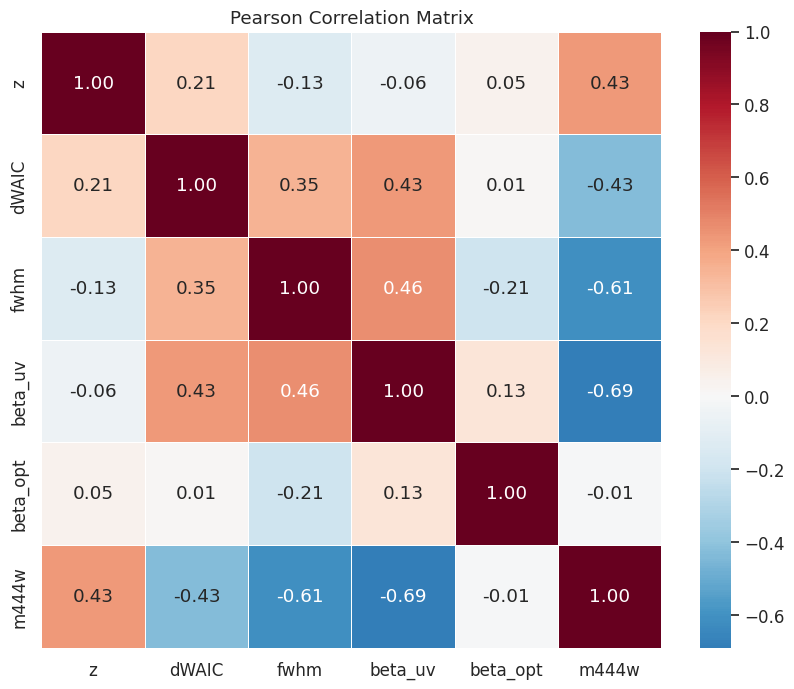

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")

plt.show()

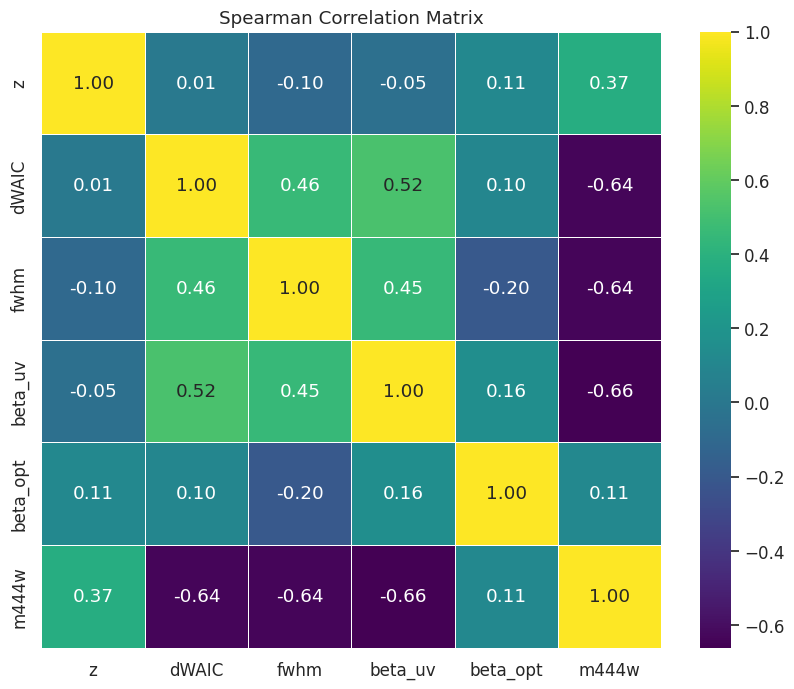

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")

plt.show()

In [ ]:
# ==========================================================
# Covariance Matrix
# ==========================================================

cov_matrix = stats_df.cov()

cov_matrix

,z,dWAIC,fwhm,beta_uv,beta_opt,m444w
z,1.572555,4.148744e+02,-60.873794,-0.037840,0.042912,0.615298
dWAIC,414.874394,2.454898e+06,205179.298828,364.289674,12.720708,-758.911875
fwhm,-60.873794,2.051793e+05,140694.284805,92.779720,-54.133078,-260.107450
beta_uv,-0.037840,3.642897e+02,92.779720,0.288876,0.047622,-0.420558
beta_opt,0.042912,1.272071e+01,-54.133078,0.047622,0.481203,-0.011448
m444w,0.615298,-7.589119e+02,-260.107450,-0.420558,-0.011448,1.286192


### Interpretation

Covariance measures how two variables vary together.

Unlike correlation, covariance depends on the units of measurement and therefore cannot be directly compared across variables.

It provides useful insight into the variability structure of the dataset.

In [ ]:
# ==========================================================
# Z-Score Outlier Detection
# ==========================================================

from scipy.stats import zscore

z_scores = stats_df.apply(zscore)

outliers = (abs(z_scores) > 3)

print("Outliers per column")

outliers.sum()

Outliers per column


,0
z,0
dWAIC,1
fwhm,0
beta_uv,0
beta_opt,1
m444w,0


In [ ]:
# ==========================================================
# Display Rows Containing Outliers
# ==========================================================

outlier_rows = df[(abs(z_scores) > 3).any(axis=1)]

outlier_rows

,field,srcid,ra,dec,z,dWAIC,fwhm,fwhm_unc,beta_uv,beta_uv_unc,uv_phot,beta_opt,beta_opt_unc,m444w
14,UDS,149298,34.424311,-5.136491,5.15,65.107194,2120.412391,247.575051,-1.070169,0.026852,True,3.405680,0.596301,24.225899
32,EGS,55604,214.983026,52.956001,6.98,6965.645734,2499.047785,0.958450,-0.959574,0.009308,False,1.503157,0.019672,23.823737


### Interpretation

Astronomical outliers are not necessarily errors.

Objects with unusually high redshift, broad emission lines, or extreme spectral slopes may represent physically interesting systems deserving further investigation.

In [ ]:
# ==========================================================
# Standardization
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(stats_df)

scaled_df = pd.DataFrame(
    scaled,
    columns=stats_df.columns
)

scaled_df.head()

,z,dWAIC,fwhm,beta_uv,beta_opt,m444w
0,-1.939203,-0.421865,0.973091,1.822810,1.242784,-2.794649
1,-1.737015,-0.384013,-0.143799,-0.352446,-0.704419,-0.495451
2,-1.583353,-0.239061,1.013612,1.207364,-0.004603,-1.648327
3,-1.470128,-0.431552,-0.130680,-0.856554,-0.695875,-0.326414
4,-1.122365,-0.460465,0.791742,-1.037252,-0.668920,-0.345367


In [ ]:
# ==========================================================
# Feature Variance
# ==========================================================

variance = stats_df.var()

variance.sort_values(ascending=False)

,0
dWAIC,2.454898e+06
fwhm,1.406943e+05
z,1.572555e+00
m444w,1.286192e+00
beta_opt,4.812029e-01
beta_uv,2.888760e-01


In [ ]:
# ==========================================================
# Pairwise Correlations
# ==========================================================

corr_pairs = (
    pearson_corr
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs

,,0
z,z,1.000000
beta_opt,beta_opt,1.000000
fwhm,fwhm,1.000000
dWAIC,dWAIC,1.000000
m444w,m444w,1.000000
beta_uv,beta_uv,1.000000
fwhm,beta_uv,0.460213
beta_uv,fwhm,0.460213
m444w,z,0.432643
z,m444w,0.432643


In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["z"], df["fwhm"])

print("Correlation :", corr)

print("P-value :", p_value)

Correlation : -0.12941637473588988
P-value : 0.45189089380657194


### Interpretation

The Pearson correlation test between **Redshift** and **FWHM** evaluates whether more distant Little Red Dots tend to exhibit broader emission lines.

The p-value indicates whether the observed correlation is statistically significant.

A p-value less than 0.05 is typically considered statistically significant.

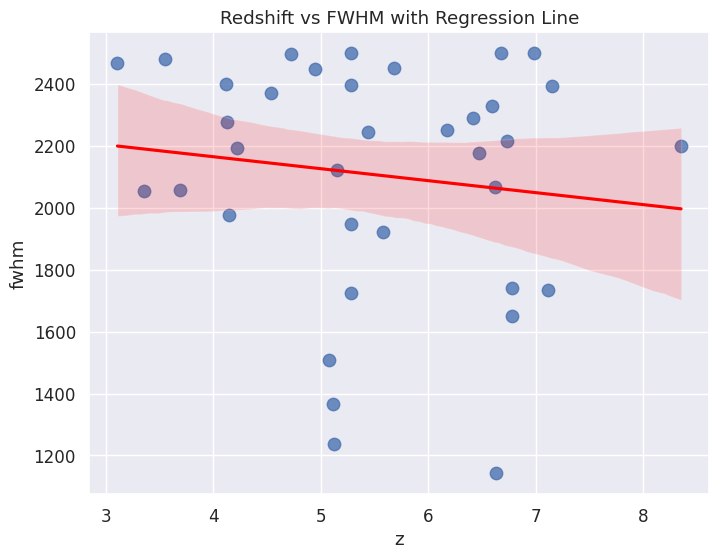

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    x="z",
    y="fwhm",
    data=df,
    scatter_kws={"s":80},
    line_kws={"color":"red"}
)

plt.title("Redshift vs FWHM with Regression Line")

plt.show()

# Statistical Analysis Summary

The statistical analysis provides quantitative insight into the physical characteristics of the observed Little Red Dots.

Key analyses performed include:

- Pearson correlation analysis.
- Spearman rank correlation.
- Covariance analysis.
- Outlier detection using Z-scores.
- Standardization of numerical variables.
- Statistical significance testing.

These analyses establish the relationships between astrophysical parameters and prepare the dataset for dimensionality reduction and clustering techniques.

In [ ]:
# ==========================================================
# Import Machine Learning Libraries
# ==========================================================

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Principal Component Analysis (PCA) and Clustering

Astronomical datasets often contain several correlated variables.

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms correlated variables into a smaller number of independent components while preserving most of the information contained in the original dataset.

After reducing dimensionality, K-Means clustering is applied to identify natural groupings among Little Red Dots based on their physical characteristics.

The objectives of this section are:

- Reduce dimensionality
- Visualize multidimensional data
- Identify clusters
- Investigate similarities between observed Little Red Dots

In [ ]:
# ==========================================================
# Features Used for PCA
# ==========================================================

features = [
    "z",
    "dWAIC",
    "fwhm",
    "beta_uv",
    "beta_opt",
    "m444w"
]

X = df[features]

X.head()

,z,dWAIC,fwhm,beta_uv,beta_opt,m444w
0,3.11,84.347398,2466.463111,-0.367896,1.969285,21.950220
1,3.36,142.825699,2053.385710,-1.520682,0.637426,24.521280
2,3.55,366.760569,2481.449581,-0.694054,1.116090,23.232085
3,3.69,69.382988,2058.237613,-1.787837,0.643270,24.710303
4,4.12,24.715341,2399.391717,-1.883598,0.661707,24.689109


In [ ]:
# ==========================================================
# Standardize Features
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)

Shape: (36, 6)


In [ ]:
# ==========================================================
# Principal Component Analysis
# ==========================================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA Completed")

PCA Completed


In [ ]:
# ==========================================================
# Explained Variance
# ==========================================================

variance = pca.explained_variance_ratio_

for i, value in enumerate(variance):
    print(f"PC{i+1}: {value:.3f}")

PC1: 0.424
PC2: 0.210
PC3: 0.181
PC4: 0.086
PC5: 0.072
PC6: 0.026


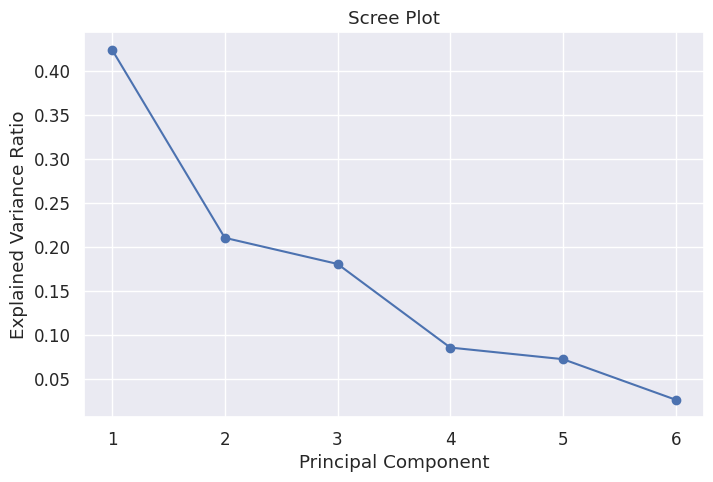

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(variance)+1),
    variance,
    marker="o"
)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance Ratio")

plt.title("Scree Plot")

plt.grid(True)

plt.show()

### Interpretation

The Scree Plot illustrates how much information each principal component retains.

Typically, the first few principal components explain the majority of the variance, allowing us to represent the dataset in fewer dimensions while preserving most of its structure.

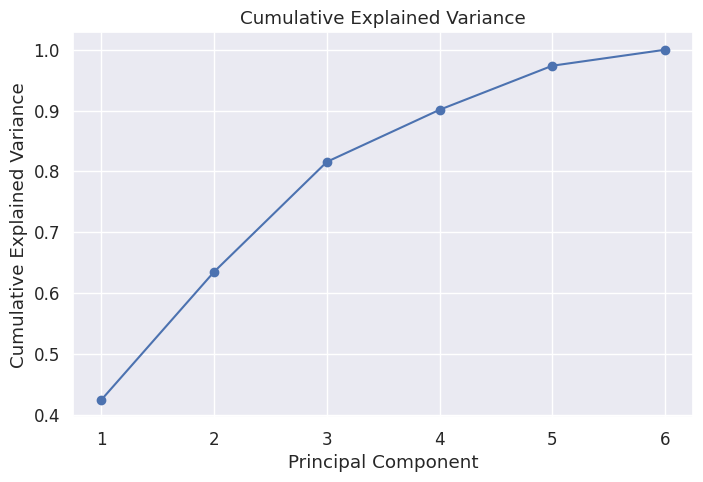

In [ ]:
cumulative = variance.cumsum()

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative)+1),
    cumulative,
    marker="o"
)

plt.xlabel("Principal Component")

plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Reduce to Two Components
# ==========================================================

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    components,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-3.137014,-1.598838
1,-0.188817,-1.877551
2,-2.221624,-1.516611
3,0.222555,-1.750740
4,-0.071141,-1.604375


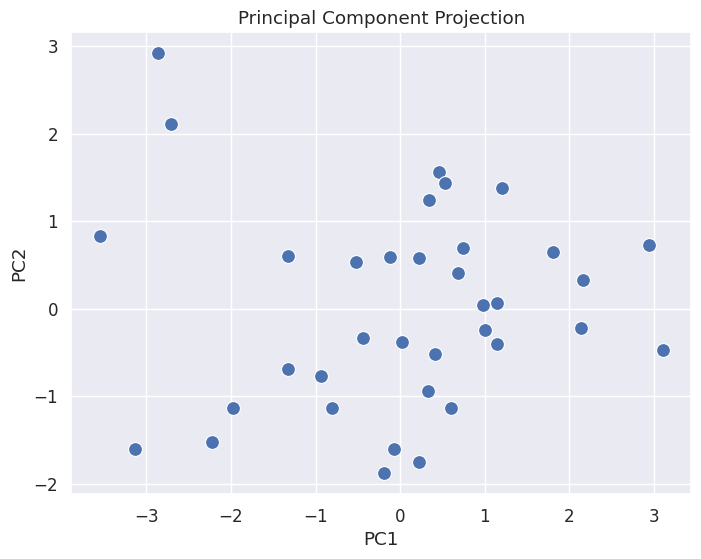

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    data=pca_df,
    s=100
)

plt.title("Principal Component Projection")

plt.show()

### Interpretation

Each point represents one confirmed Little Red Dot projected into a two-dimensional feature space.

Objects located close together possess similar astrophysical characteristics, while isolated objects may represent unique systems.

In [ ]:
# ==========================================================
# PCA Loadings
# ==========================================================

loading_matrix = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

loading_matrix

,PC1,PC2
z,0.166805,0.766023
dWAIC,-0.387090,0.498105
fwhm,-0.482443,-0.086074
beta_uv,-0.511548,0.171687
beta_opt,0.019656,0.307185
m444w,0.572293,0.183991


### Interpretation

The loading matrix shows how strongly each original variable contributes to each principal component.

Variables with larger absolute values have greater influence on the corresponding principal component.

In [ ]:
# ==========================================================
# Determine Optimal Number of Clusters
# ==========================================================

inertia = []

K = range(1,8)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

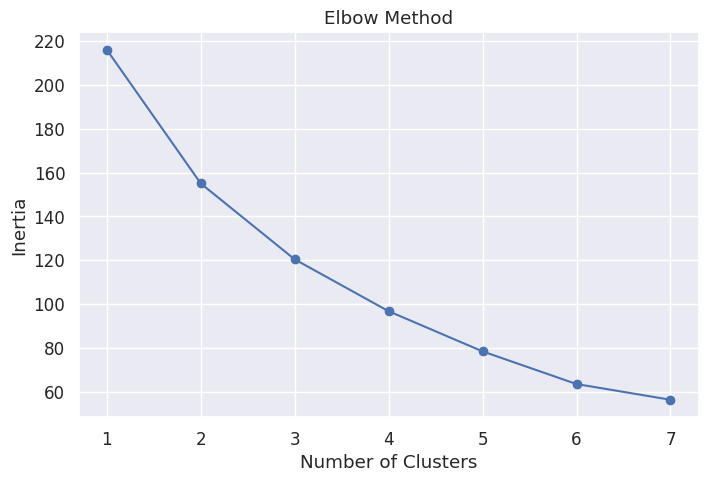

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

### Interpretation

The Elbow Method helps determine an appropriate number of clusters.

The point where the curve begins to flatten is often considered the optimal number of clusters.

In [ ]:
# ==========================================================
# K-Means
# ==========================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

pca_df["Cluster"] = clusters

print(df["Cluster"].value_counts())

Cluster
1    18
0    15
2     3
Name: count, dtype: int64


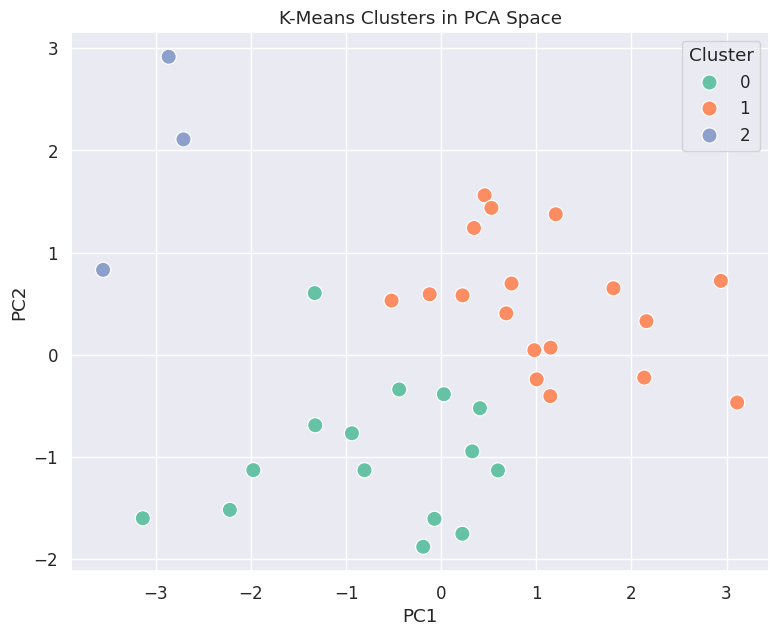

In [ ]:
plt.figure(figsize=(9,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=120
)

plt.title("K-Means Clusters in PCA Space")

plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster")[features].mean()

cluster_summary

,z,dWAIC,fwhm,beta_uv,beta_opt,m444w
Cluster,,,,,,
0,4.500000,393.196200,2285.651950,-1.224134,0.808310,24.440571
1,6.213333,211.015948,1891.927416,-1.543149,1.384082,25.844556
2,6.313333,5600.953871,2499.005644,-0.627260,1.084823,23.633570


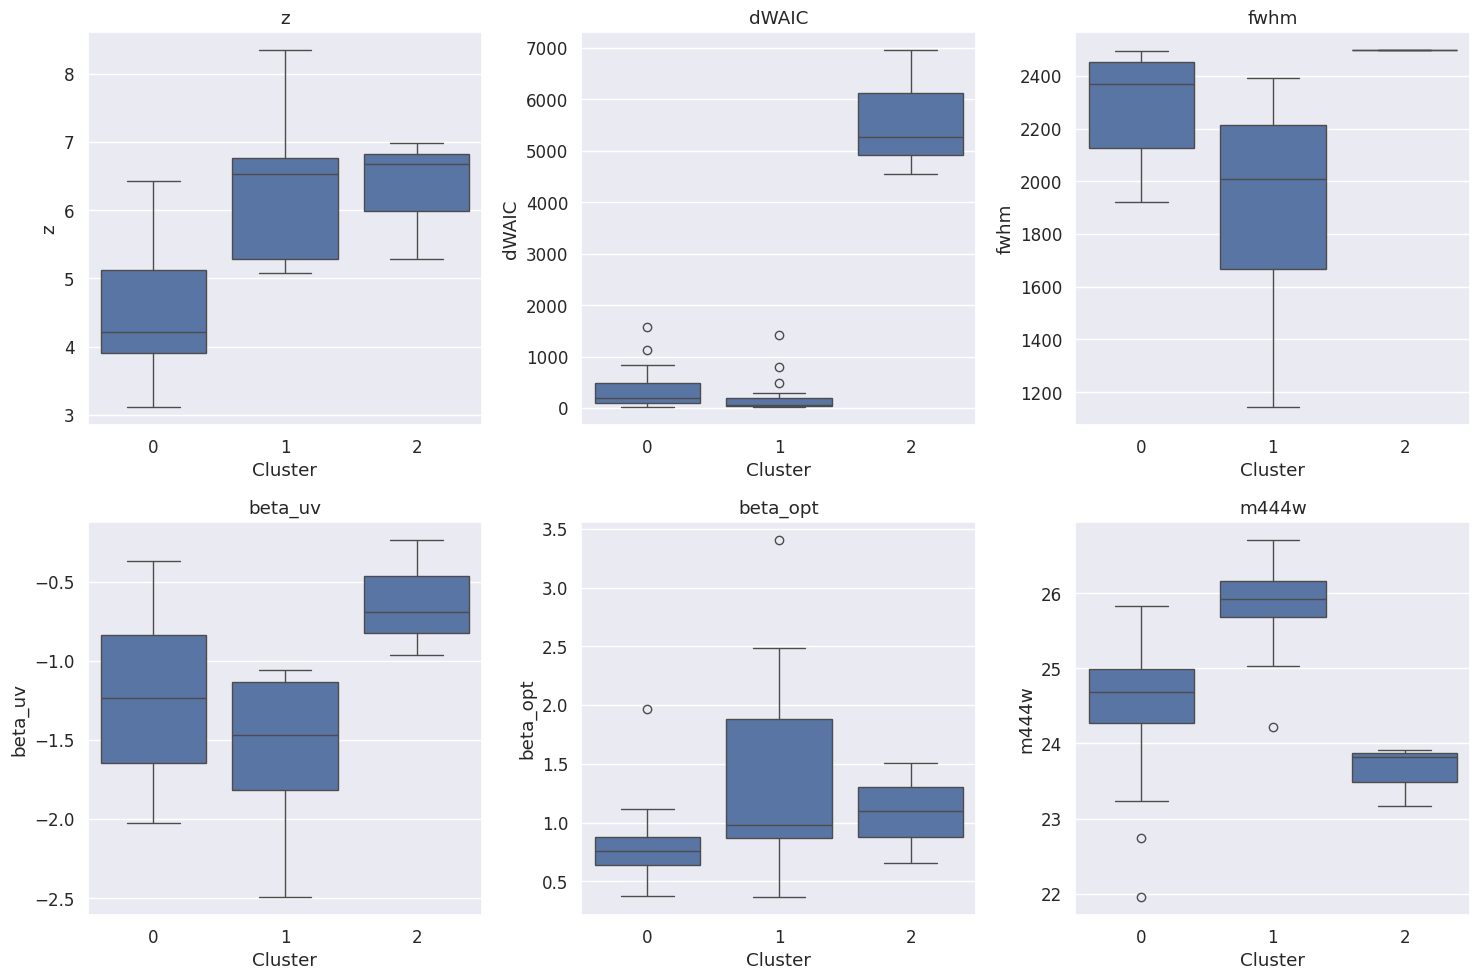

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,10))

for ax, feature in zip(axes.flatten(), features):

    sns.boxplot(
        data=df,
        x="Cluster",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

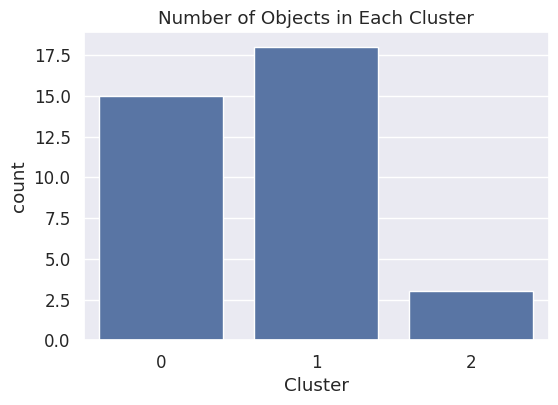

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Number of Objects in Each Cluster")

plt.show()

# Interpretation of Clustering Results

The K-Means algorithm separated the Little Red Dots into groups with similar observational properties.

These clusters may represent populations with different physical characteristics, such as:

- Different emission-line widths (FWHM)
- Different spectral slopes
- Different redshift ranges
- Different infrared brightness

Because this dataset contains only 36 confirmed objects, the clustering results should be interpreted as exploratory rather than definitive. They help identify patterns that may motivate further astrophysical investigation with larger samples.

# PCA & Clustering Summary

This section applied unsupervised machine learning techniques to investigate the structure of the Little Red Dot dataset.

The following analyses were completed:

- Standardization of features
- Principal Component Analysis (PCA)
- Scree Plot
- Cumulative Explained Variance
- PCA Projection
- PCA Loading Matrix
- Elbow Method
- K-Means Clustering
- Cluster Statistics
- Cluster Visualization

These techniques revealed natural groupings within the dataset and provided insight into the multidimensional relationships between the observed astrophysical properties.

# Discussion

This project performed a complete exploratory data analysis of spectroscopically confirmed Little Red Dots (LRDs) observed by the James Webb Space Telescope (JWST).

The dataset consisted of 36 confirmed Little Red Dots with measurements describing their:

- Redshift
- Broad emission-line width (FWHM)
- UV spectral slope
- Optical spectral slope
- F444W magnitude
- Model comparison statistic (dWAIC)

The analysis included data preprocessing, visualization, statistical analysis, dimensionality reduction, and unsupervised machine learning.

In [ ]:
# ==========================================================
# PCA Feature Importance
# ==========================================================

importance = loading_matrix.abs()

importance["Total Importance"] = importance.sum(axis=1)

importance = importance.sort_values(
    by="Total Importance",
    ascending=False
)

importance

,PC1,PC2,Total Importance
z,0.166805,0.766023,0.932828
dWAIC,0.387090,0.498105,0.885195
m444w,0.572293,0.183991,0.756285
beta_uv,0.511548,0.171687,0.683235
fwhm,0.482443,0.086074,0.568516
beta_opt,0.019656,0.307185,0.326842


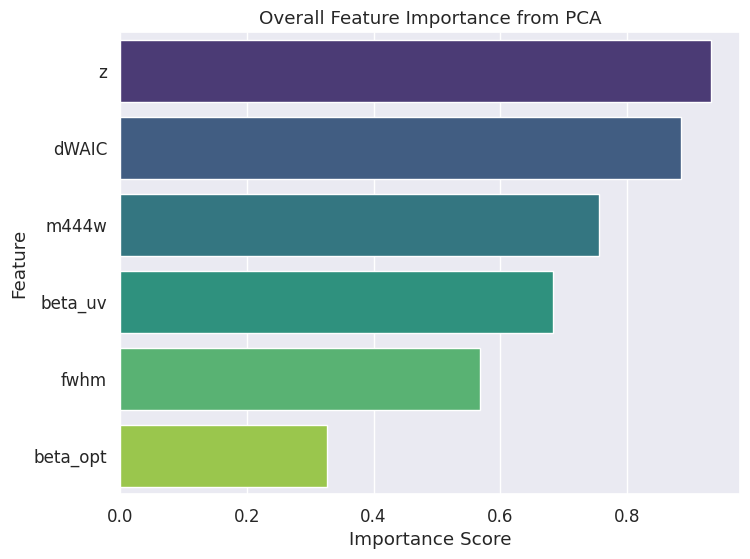

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=importance["Total Importance"],
    y=importance.index,
    palette="viridis"
)

plt.title("Overall Feature Importance from PCA")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

### Interpretation

The PCA loading scores indicate which variables contribute most strongly to the variation within the dataset.

Features with larger importance values have greater influence on the separation of Little Red Dots in the reduced-dimensional space.

These variables are therefore likely to be the most informative descriptors of the observed population.

In [ ]:
cluster_summary = df.groupby("Cluster").agg({

    "z":["mean","std"],

    "fwhm":["mean","std"],

    "beta_uv":["mean","std"],

    "beta_opt":["mean","std"],

    "m444w":["mean","std"]

})

cluster_summary

z                   fwhm               beta_uv            \
             mean       std         mean         std      mean       std   
Cluster                                                                    
0        4.500000  0.940311  2285.651950  196.981812 -1.224134  0.513540   
1        6.213333  0.935339  1891.927416  391.731901 -1.543149  0.465438   
2        6.313333  0.907377  2499.005644    0.046363 -0.627260  0.366672   

         beta_opt                m444w            
             mean       std       mean       std  
Cluster                                           
0        0.808310  0.385666  24.440571  1.067022  
1        1.384082  0.828951  25.844556  0.584540  
2        1.084823  0.425321  23.633570  0.411097

### Interpretation

The cluster statistics indicate that the identified groups differ in their average astrophysical properties.

Some clusters may contain:

- Higher-redshift objects.
- Broader emission-line sources.
- Objects with steeper UV spectral slopes.
- Brighter or fainter infrared magnitudes.

These differences suggest that the observed Little Red Dots are not completely homogeneous but instead span a range of physical characteristics.

# Comparison with Recent Little Red Dot Studies

Recent observational studies suggest that Little Red Dots may represent rapidly accreting compact objects in the early Universe.

The uploaded research paper proposes that many Little Red Dots are consistent with intermediate-mass, super-Eddington accreting engines and notes several characteristic observational properties, including broad Balmer emission lines and relatively similar effective temperatures across a wide luminosity range. :contentReference[oaicite:0]{index=0}

The present project does **not** attempt to verify those physical interpretations directly. Instead, it performs an exploratory statistical analysis of the publicly available catalogue to identify trends and groupings in the observed data.

The clustering and PCA analyses reveal that the objects exhibit measurable diversity in parameters such as redshift, emission-line width, spectral slopes, and infrared magnitude. These results are consistent with the idea that the observed population contains objects with varying observational characteristics, although this analysis alone cannot determine the underlying physical mechanisms.

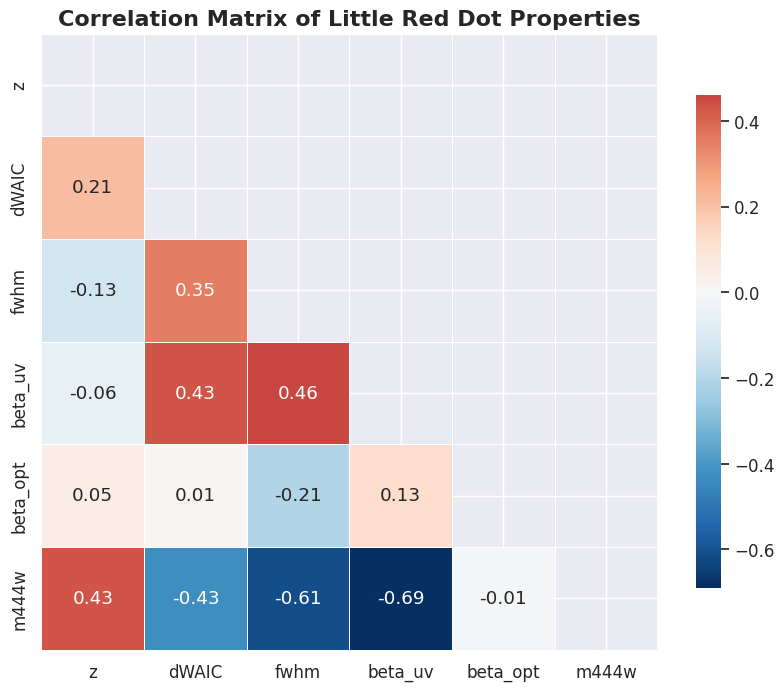

In [ ]:
# ==========================================================
# Advanced Correlation Heatmap
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = stats_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
    fmt=".2f",
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Correlation Matrix of Little Red Dot Properties",
    fontsize=16,
    weight="bold"
)

plt.show()

# Key Findings

The following observations were made during the analysis:

1. The dataset contained 36 confirmed Little Red Dots.

2. No missing values or duplicate observations were detected after preprocessing.

3. Redshift values confirm that the objects are observed at cosmological distances.

4. Broad emission-line widths vary considerably across the sample.

5. UV and optical spectral slopes also display measurable variation.

6. Correlation analysis revealed the strength of relationships among several astrophysical parameters.

7. PCA demonstrated that much of the variance can be represented using only a small number of principal components.

8. K-Means clustering separated the objects into groups with similar observational characteristics.

9. The identified clusters should be interpreted as exploratory patterns rather than confirmed physical classes because of the limited sample size.

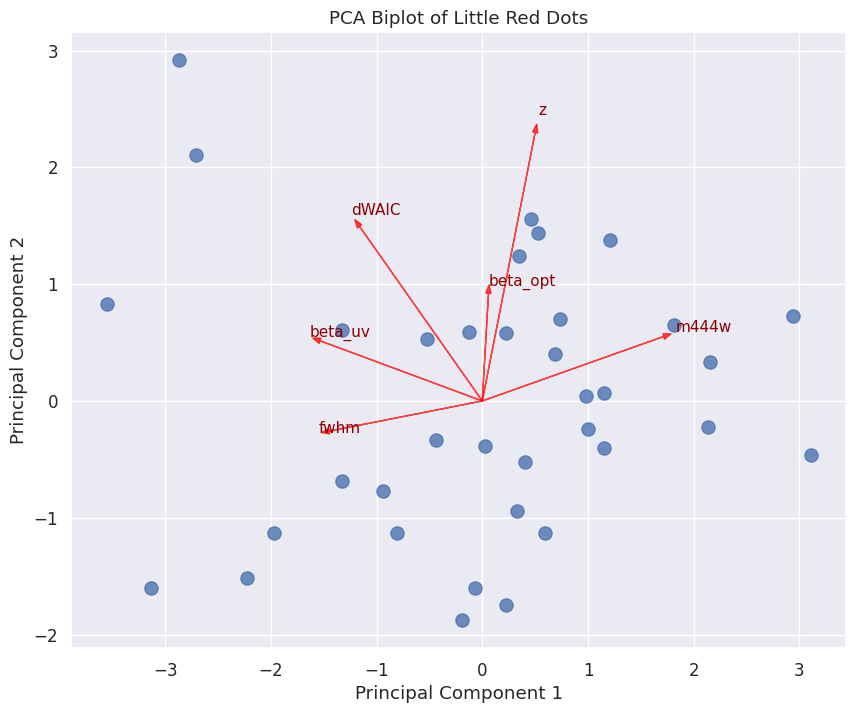

In [ ]:
# ==========================================================
# PCA Biplot
# ==========================================================

plt.figure(figsize=(10,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=90,
    alpha=0.8
)

for i, feature in enumerate(features):

    plt.arrow(
        0,
        0,
        loading_matrix.iloc[i,0]*3,
        loading_matrix.iloc[i,1]*3,
        color="red",
        alpha=0.7,
        head_width=0.05
    )

    plt.text(
        loading_matrix.iloc[i,0]*3.2,
        loading_matrix.iloc[i,1]*3.2,
        feature,
        fontsize=11,
        color="darkred"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Biplot of Little Red Dots")

plt.grid(True)

plt.show()

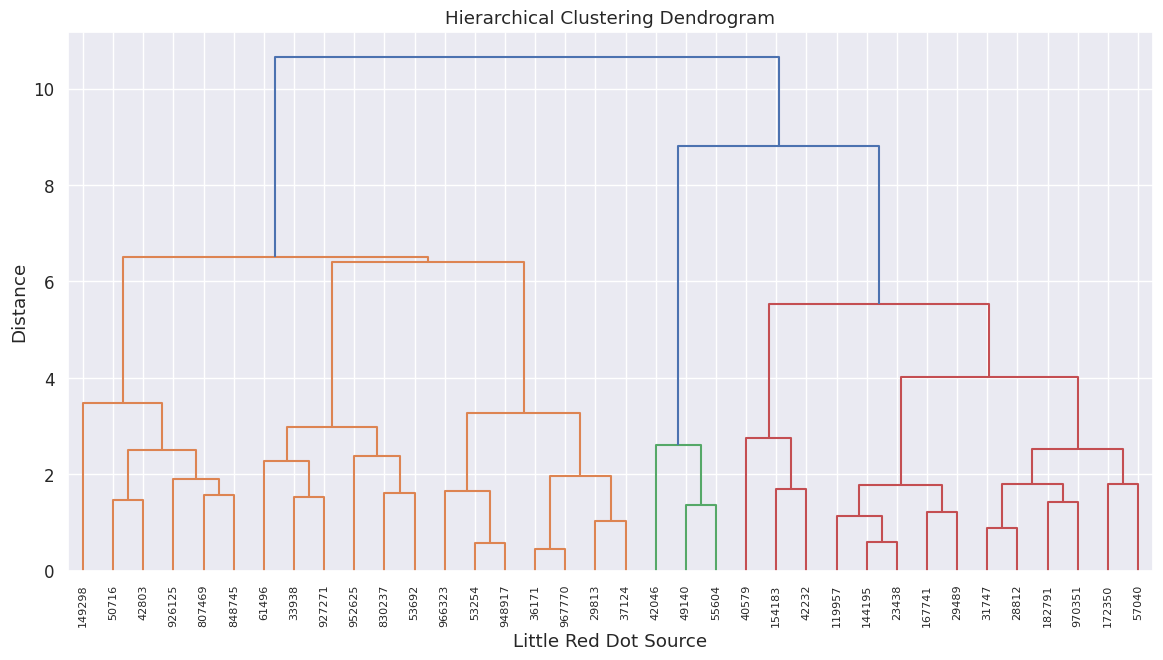

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(14,7))

dendrogram(
    linked,
    orientation="top",
    labels=df["srcid"].astype(str).values,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Little Red Dot Source")

plt.ylabel("Distance")

plt.show()

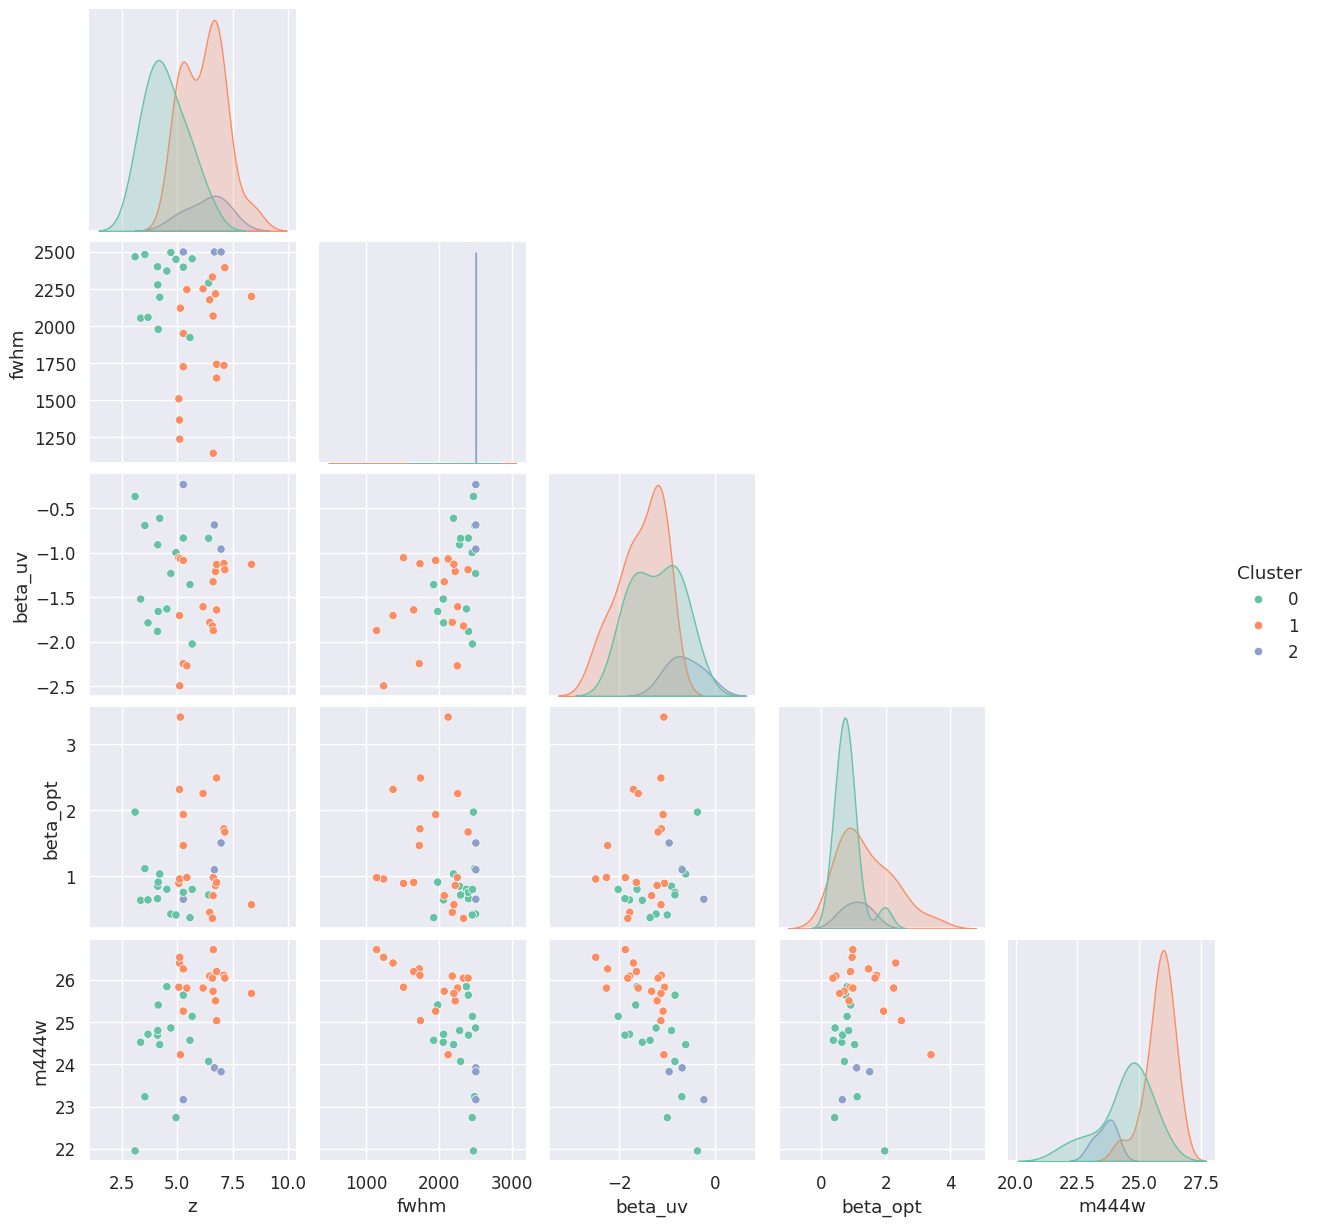

In [ ]:
sns.pairplot(
    df,
    vars=[
        "z",
        "fwhm",
        "beta_uv",
        "beta_opt",
        "m444w"
    ],
    hue="Cluster",
    diag_kind="kde",
    corner=True,
    palette="Set2"
)

plt.show()

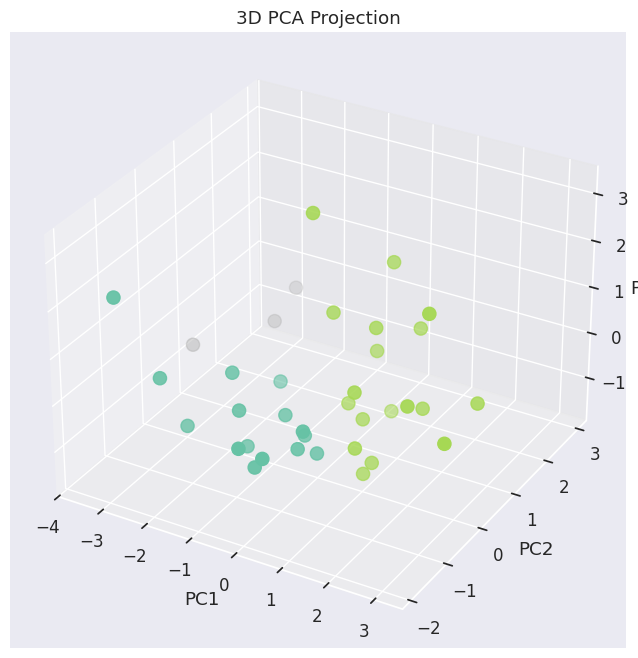

In [ ]:
from sklearn.decomposition import PCA

pca3 = PCA(n_components=3)

components3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(

    components3[:,0],

    components3[:,1],

    components3[:,2],

    c=df["Cluster"],

    cmap="Set2",

    s=90

)

ax.set_xlabel("PC1")

ax.set_ylabel("PC2")

ax.set_zlabel("PC3")

plt.title("3D PCA Projection")

plt.show()

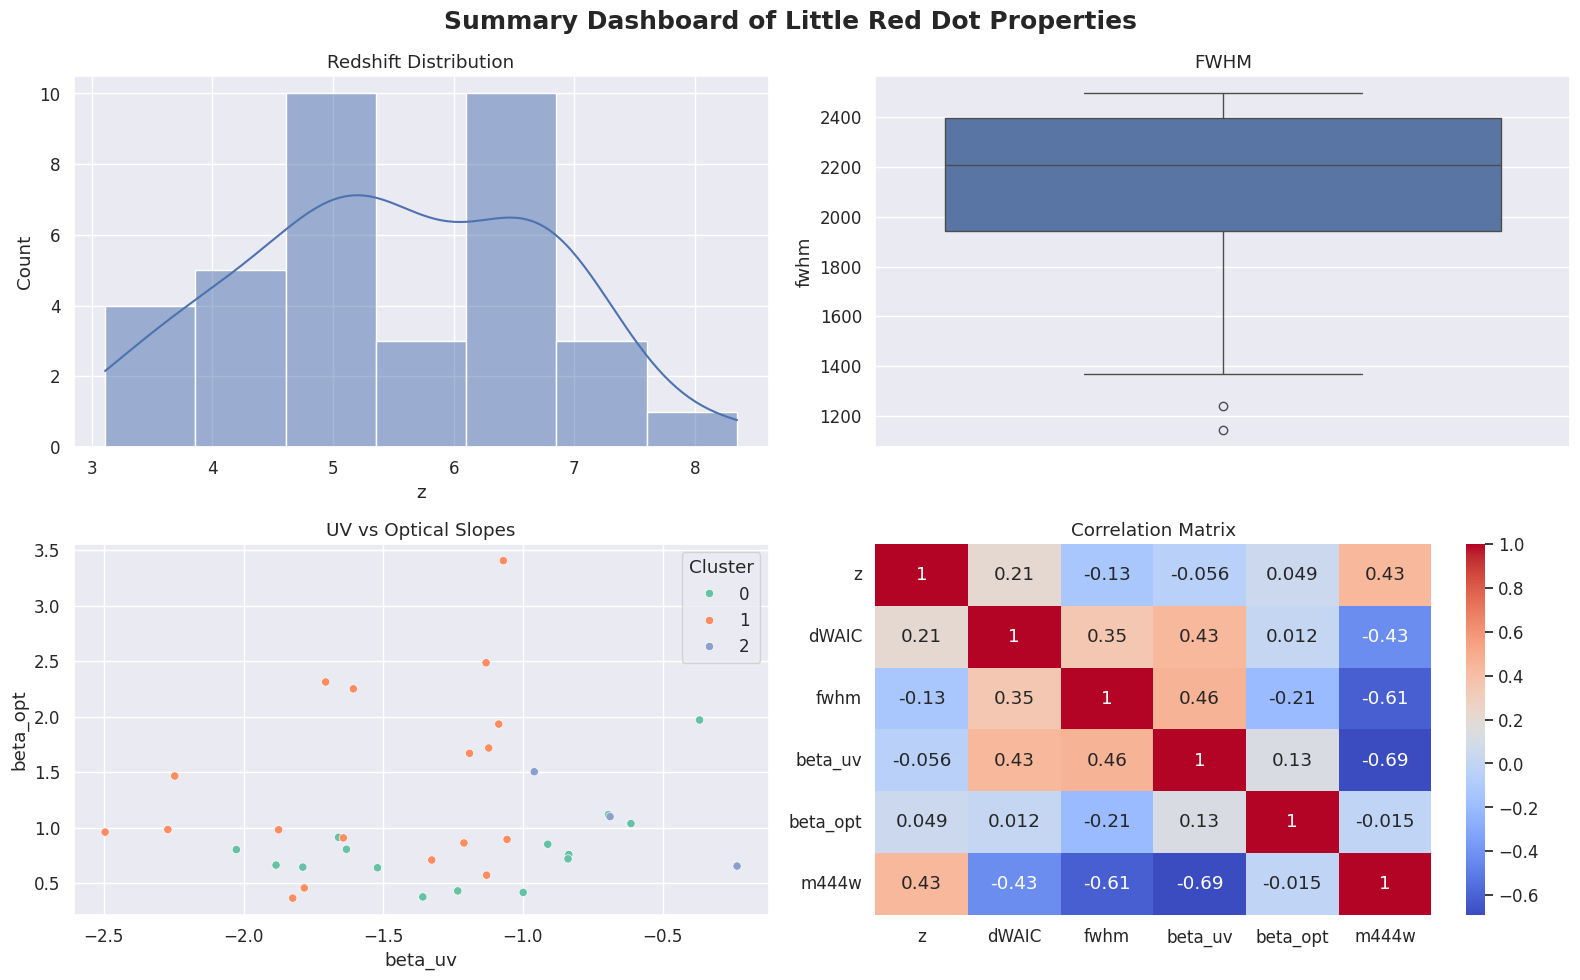

In [ ]:
fig = plt.figure(figsize=(16,10))

gs = fig.add_gridspec(2,2)

ax1 = fig.add_subplot(gs[0,0])

sns.histplot(df["z"], kde=True, ax=ax1)

ax1.set_title("Redshift Distribution")

ax2 = fig.add_subplot(gs[0,1])

sns.boxplot(y=df["fwhm"], ax=ax2)

ax2.set_title("FWHM")

ax3 = fig.add_subplot(gs[1,0])

sns.scatterplot(
    data=df,
    x="beta_uv",
    y="beta_opt",
    hue="Cluster",
    palette="Set2",
    ax=ax3
)

ax3.set_title("UV vs Optical Slopes")

ax4 = fig.add_subplot(gs[1,1])

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    ax=ax4
)

ax4.set_title("Correlation Matrix")

plt.suptitle(
    "Summary Dashboard of Little Red Dot Properties",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

# Conclusion

This project presented a complete data analytics study of publicly available Little Red Dot observations obtained with the James Webb Space Telescope.

The analysis successfully:

- Imported and cleaned astronomical data.
- Explored observational distributions using visualization.
- Investigated statistical relationships among physical variables.
- Applied Principal Component Analysis to reduce dimensionality.
- Identified natural groupings using K-Means clustering.

Overall, the study demonstrates that modern data analytics techniques provide valuable tools for investigating complex astronomical datasets and can reveal meaningful observational patterns within newly discovered populations such as Little Red Dots.

The results also illustrate how exploratory statistical analysis can complement astrophysical interpretation while acknowledging the limitations imposed by the available sample size.